### Learn Tinygrad/Tensor

- 无法直接`from tinygrad import Device`
- 由于tinygrad仓库是在本地，要先
  1. 显式安装`# 2. 用 editable 模式安装（必须在 tinygrad 文件夹根目录执行，注意最后的点 . ）
python -m pip install -e .`
  2. 或者按照下述方式，临时添加
- 先确认内核正常？

In [6]:
import sys
print("Jupyter 当前使用的 Python 路径：")
print(sys.executable)
print("\nsite-packages 路径：")
for path in sys.path:
    if 'site-packages' in path:
        print(path)

Jupyter 当前使用的 Python 路径：
F:\anaconda\envs\tinygrad\python.exe

site-packages 路径：
F:\anaconda\envs\tinygrad\Lib\site-packages
F:\anaconda\envs\tinygrad\Lib\site-packages\win32
F:\anaconda\envs\tinygrad\Lib\site-packages\win32\lib
F:\anaconda\envs\tinygrad\Lib\site-packages\Pythonwin


- 尝试import（临时）

In [8]:
import sys
import os

tinygrad_root = r'F:\pycharm\projects\tinygrad'   # ← 确认这是 tinygrad 仓库的根目录

print("当前 sys.path 前几项：")
for p in sys.path[:10]:
    print(p)

print("\n正在添加的路径：", tinygrad_root)
print("该路径是否存在？", os.path.exists(tinygrad_root))
print("里面是否有 tinygrad 文件夹？", os.path.exists(os.path.join(tinygrad_root, "tinygrad")))

# 添加路径（推荐用 insert(0, ...) 并用绝对路径）
sys.path.insert(0, tinygrad_root)

# 再打印一次确认添加成功
print("\n添加后 sys.path[0] =", sys.path[0])

# 尝试导入
try:
    from tinygrad import Device
    print("✅ 导入成功！")
    print("默认设备:", Device.DEFAULT)
except Exception as e:
    print("❌ 还是失败，错误：", type(e).__name__, str(e))

当前 sys.path 前几项：
F:\pycharm\projects\tinygrad
F:\anaconda\envs\tinygrad\python313.zip
F:\anaconda\envs\tinygrad\DLLs
F:\anaconda\envs\tinygrad\Lib
F:\anaconda\envs\tinygrad

F:\anaconda\envs\tinygrad\Lib\site-packages
__editable__.tinygrad-0.12.0.finder.__path_hook__
F:\anaconda\envs\tinygrad\Lib\site-packages\win32
F:\anaconda\envs\tinygrad\Lib\site-packages\win32\lib

正在添加的路径： F:\pycharm\projects\tinygrad
该路径是否存在？ True
里面是否有 tinygrad 文件夹？ True

添加后 sys.path[0] = F:\pycharm\projects\tinygrad
✅ 导入成功！
默认设备: CL


In [2]:
from tinygrad import Device

In [3]:
print(Device.DEFAULT)

CL


### micrograd:

In [4]:
import math
import numpy as np

- 先诊断Graphviz模块是否可用

In [1]:
import sys
print("Python解释器:", sys.executable)
print("Graphviz模块:", end=" ")
try:
    import graphviz
    print("✓ 可用")
except ImportError as e:
    print(f"✗ 错误: {e}")

Python解释器: F:\anaconda\envs\tinygrad\python.exe
Graphviz模块: ✓ 可用


In [3]:
import os
import sys
import subprocess
import platform

print("=== Graphviz 诊断报告 ===")
print(f"操作系统: {platform.system()} {platform.release()}")
print(f"Python路径: {sys.executable}")

# 1. 检查当前 PATH
print(f"\n当前 PATH 包含 Graphviz 吗?")
path_dirs = os.environ["PATH"].split(os.pathsep)
graphviz_paths = [p for p in path_dirs if "graphviz" in p.lower() or "dot" in p.lower()]
if graphviz_paths:
    for p in graphviz_paths:
        print(f"✅ 找到: {p}")
else:
    print("❌ PATH 中没有找到 Graphviz")

# 2. 查找常见安装位置
print(f"\n搜索常见 Graphviz 安装位置:")
common_paths = [
    r"C:\Program Files\Graphviz\bin",
    r"C:\Program Files (x86)\Graphviz\bin", 
    r"C:\Users\{}\AppData\Local\Packages\Graphviz\bin".format(os.getenv('USERNAME')),
    r"D:\Graphviz\bin",
    r"E:\Graphviz\bin",
    r"C:\Users\Public\Graphviz\bin",
    r"C:\msys64\mingw64\bin",  # MSYS2
]

for path in common_paths:
    dot_exe = os.path.join(path, "dot.exe")
    if os.path.isfile(dot_exe):
        print(f"✅ 找到 dot.exe: {dot_exe}")
    elif os.path.isdir(path):
        print(f"📁 存在目录: {path}")

# 3. 测试 dot 命令
print(f"\n测试 'dot' 命令:")
try:
    result = subprocess.run(['dot', '-V'], capture_output=True, text=True, shell=True)
    print(f"✅ dot 命令可用: {result.stderr if result.stderr else result.stdout}")
except FileNotFoundError:
    print("❌ dot 命令未找到")

# 4. 检查 graphviz Python 包
print(f"\n检查 graphviz 包:")
try:
    import graphviz
    print(f"✅ graphviz Python 包: {graphviz.__version__}")
    # 检查后端配置
    print(f"   后端路径: {graphviz.backend.__file__}")
except ImportError as e:
    print(f"❌ 导入失败: {e}")

print(f"\n=== 诊断完成 ===")

=== Graphviz 诊断报告 ===
操作系统: Windows 11
Python路径: F:\anaconda\envs\tinygrad\python.exe

当前 PATH 包含 Graphviz 吗?
❌ PATH 中没有找到 Graphviz

搜索常见 Graphviz 安装位置:

测试 'dot' 命令:
✅ dot 命令可用: dot - graphviz version 14.1.2 (0)


检查 graphviz 包:
✅ graphviz Python 包: 0.21
   后端路径: F:\anaconda\envs\tinygrad\Lib\site-packages\graphviz\backend\__init__.py

=== 诊断完成 ===


In [2]:
import os
from graphviz import Digraph

# === 正确的 PATH 添加方式（tinygrad 环境）===
graphviz_bin = r'F:\anaconda\envs\tinygrad\Library\bin'

# 添加到 PATH
if graphviz_bin not in os.environ['PATH']:
    os.environ['PATH'] += os.pathsep + graphviz_bin

print("当前添加的 Graphviz bin 路径:", graphviz_bin)
print("dot.exe 是否存在？", os.path.exists(os.path.join(graphviz_bin, 'dot.exe')))


当前添加的 Graphviz bin 路径: F:\anaconda\envs\tinygrad\Library\bin
dot.exe 是否存在？ True


### forward

In [4]:
class Value:
    def __init__(self,data,_children=(),_op=''):
        self.data=data
        self._prev=set(_children) # 子节点
        self._op=_op #构建计算图，保留操作

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        out = Value(self.data+other.data,(self,other),'+')
        return out

    def __mul__(self,other):
        out = Value(self.data*other.data,(self,other),'*')
        return out

a = Value(2.)
b = Value(-3.)
c = Value(10.)
d = a*b+c
d
    

Value(data=4.0)

In [5]:
from graphviz import Digraph
def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'}) # L->R

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # 制造节点
        dot.node(name =uid,label="{data %.4f}" %(n.data,),shape='record')
        if n._op:
            dot.node(name = uid+n._op,label = n._op)
            dot.edge(uid+n._op,uid)
    for n1,n2 in edges:
        # 连接
        dot.edge(str(id(n1)),str(id(n2))+n2._op)

    return dot

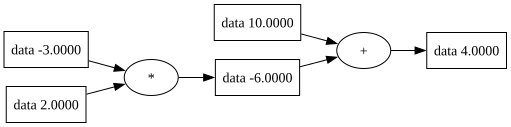

In [6]:
draw_dot(d)

### backward：
- 增加grad

- 梯度计算公式
$$\nabla_{\mathbf{x}} f = 
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix}$$

$$\nabla_{\mathbf{W}} f = 
\begin{bmatrix}
\frac{\partial f}{\partial w_{11}} & \frac{\partial f}{\partial w_{12}} & \cdots & \frac{\partial f}{\partial w_{1n}} \\
\frac{\partial f}{\partial w_{21}} & \frac{\partial f}{\partial w_{22}} & \cdots & \frac{\partial f}{\partial w_{2n}} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial f}{\partial w_{m1}} & \frac{\partial f}{\partial w_{m2}} & \cdots & \frac{\partial f}{\partial w_{mn}}
\end{bmatrix}$$
- 链式法则
    - non-vector
$$\frac{\partial f}{\partial x} = \frac{\partial f}{\partial u} \cdot \frac{\partial u}{\partial x}$$
    - vector
$$\frac{\partial f}{\partial x} = \sum_{i=1}^n \frac{\partial f}{\partial u_i} \frac{\partial u_i}{\partial x}$$
    - matrix
$$\frac{\partial \mathbf{y}}{\partial \mathbf{x}} = 
\frac{\partial \mathbf{y}}{\partial \mathbf{u}} \frac{\partial \mathbf{u}}{\partial \mathbf{x}} = \mathbf{J}_{\mathbf{y}}(\mathbf{u}) \mathbf{J}_{\mathbf{u}}(\mathbf{x})$$
$$\mathbf{J}_{\mathbf{f}}(\mathbf{x}) = 
\begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \frac{\partial f_1}{\partial x_2} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\frac{\partial f_2}{\partial x_1} & \frac{\partial f_2}{\partial x_2} & \cdots & \frac{\partial f_2}{\partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial f_m}{\partial x_1} & \frac{\partial f_m}{\partial x_2} & \cdots & \frac{\partial f_m}{\partial x_n}
\end{bmatrix}$$

- 自动微分公式（计算图）
    - forward
$$\dot{x}_i = \sum_{j \in \text{parents}(i)} \frac{\partial x_i}{\partial x_j} \dot{x}_j$$
    - backward
$$\bar{x}_j = \sum_{i \in \text{children}(j)} \frac{\partial x_i}{\partial x_j} \bar{x}_i$$
    - graph-grad-sum
$$\frac{\partial L}{\partial v_i} = \sum_{j \in \text{children}(i)} \frac{\partial L}{\partial v_j} \frac{\partial v_j}{\partial v_i}$$

In [4]:
import math
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.label = label
        self.grad = 0.0#----------------add
        self._prev=set(_children) # 子节点
        self._op=_op #构建计算图，保留操作

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        out = Value(self.data+other.data,(self,other),'+')
        return out

    def __mul__(self,other):
        out = Value(self.data*other.data,(self,other),'*')
        return out

    def tanh(self):
        # dtanh(x)/dx = 1-tanh(x)^2
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')
        return out


In [ ]:
import matplat as plt


In [2]:
from graphviz import Digraph
def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'}) # L->R

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # 制造节点
        dot.node(name =uid,label="{%s|data %.4f|grad %.4f}" %(n.label,n.data,n.grad),shape='record')#-----------add
        if n._op:
            dot.node(name = uid+n._op,label = n._op)
            dot.edge(uid+n._op,uid)
    for n1,n2 in edges:
        # 连接
        dot.edge(str(id(n1)),str(id(n2))+n2._op)

    return dot

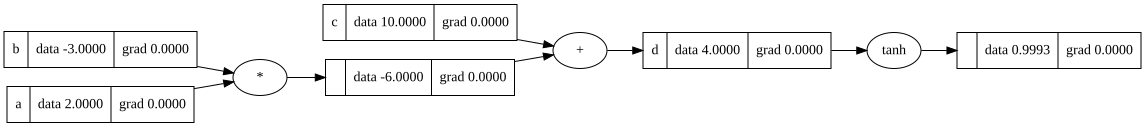

In [5]:
a = Value(2.,label='a')
b = Value(-3.,label='b')
c = Value(10.,label='c')
d = a*b+c
d.label='d'
e = d.tanh()
e.label='e'
draw_dot(e)

- 手动求导

In [16]:
# opt
def lol():
    h=0.0001
    a = Value(2.,label='a')
    b = Value(-3.,label='b')
    c = Value(10.,label='c')
    d = a*b+c
    d.label='d'
    L1=d.data;

    a = Value(2.+h,label='a')
    b = Value(-3.,label='b')
    c = Value(10.,label='c')
    d = a*b+c
    d.label='d'
    L2=d.data;

    print((L2-L1)/h)#手动求导dd/dh
    # dd/d_=1.
    # d_/da=b
    # dd/da=dd/d_*d_/da=b

lol()

-3.000000000010772


- 自动传播

In [7]:
import math
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.label = label
        self._backward = lambda:None # 更新公式由其构成的表达式决定
        self.grad = 0.0
        self._prev=set(_children) # 子节点
        self._op=_op #构建计算图，保留操作

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        out = Value(self.data+other.data,(self,other),'+')

        def _backward():
            self.grad = 1.0*out.grad
            other.grad = 1.0*out.grad
        out.backward = _backward()
        return out

    def __mul__(self,other):
        out = Value(self.data*other.data,(self,other),'*')

        def _backward():
            self.grad = other.data*out.grad
            other.grad = self.data*out.grad
        out.backward = _backward()
        return out

    def tanh(self):
        # dtanh(x)/dx = 1-tanh(x)^2
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad = (1.0-t**2)*out.grad
        out.backward = _backward()
        return out


In [ ]:
# opt
def lol1():
    
    a = Value(2.,label='a')
    b = Value(-3.,label='b')
    c = Value(10.,label='c')
    d = a*b+c
    d.label='d'
    e = d.tanh()
    e.label='e'
    e.grad = 1.0 # 假设
    e._backward()

    d._backward()
    draw_dot(e)


    print((L2-L1)/h)#手动求导dd/dh
    # dd/d_=1.
    # d_/da=b
    # dd/da=dd/d_*d_/da=b

lol1()